#### import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from transformers import BertTokenizer, TFBertModel
import soundfile as sf
from tqdm import tqdm


In [8]:
!pip install safetensors


In [6]:
import os
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio
import numpy as np


def load_protocol(protocol_path):
    df = pd.read_csv(protocol_path, sep=" ", header=None)
    df.columns = ["speaker_id", "file_id", "dash", "system_id", "key"]
    df["label"] = df["key"].map({"bonafide": 0, "spoof": 1})
    return df[["file_id", "label"]]


In [7]:
train_df = load_protocol("../LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")
dev_df   = load_protocol("../LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt")
eval_df = load_protocol("../LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt")


In [8]:
from transformers import BertTokenizer, TFBertModel

yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert = TFBertModel.from_pretrained("bert-base-uncased", from_pt=True, use_safetensors=True )


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already

In [9]:
print(tf.__version__)

2.20.0


In [10]:
QUESTION = "Is this audio real human speech or spoofed synthetic speech?"


In [11]:
def get_question_embedding(question):
    tokens = tokenizer(question, return_tensors="tf", truncation=True, padding=True, max_length=32)
    outputs = bert(**tokens)
    return outputs.pooler_output[0].numpy()   # shape (768,)


In [12]:
QUESTION_EMB = get_question_embedding(QUESTION)


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


In [19]:
import os
import time
import numpy as np
import soundfile as sf
import tensorflow as tf
import tensorflow_hub as hub
from tqdm import tqdm

# Load YAMNet once
yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

# -------------------------------
# Audio loader (memory-friendly)
# -------------------------------
def load_flac_soundfile(path, target_sr=16000):
    """
    Load a FLAC file as mono float32 tensor, resampled to target_sr.
    """
    wav, sr = sf.read(path, dtype="float32", always_2d=True)
    wav = wav.mean(axis=1)  # convert to mono
    wav = tf.convert_to_tensor(wav, dtype=tf.float32)
    
    if sr != target_sr:
        wav = tf.audio.resample(wav, sr, target_sr)
    
    return wav

# -------------------------------
# YAMNet embedding extractor
# -------------------------------
def get_yamnet_embedding(path):
    wav = load_flac_soundfile(path)
    scores, embeddings, _ = yamnet(wav)
    # mean pooling over time frames -> 1024-D
    return tf.reduce_mean(embeddings, axis=0).numpy()

# -------------------------------
# Batch extractor with memmap, tqdm, ETA, and checkpoints
# -------------------------------
def extract_audio_dataset_memmap(df, base_path, save_path, embedding_dim=1024, checkpoint_every=500):
    """
    Extract audio embeddings for a dataset and save to memmap incrementally.
    
    Args:
        df: DataFrame with column "file_id" containing file names without extension
        base_path: path to folder containing FLAC files
        save_path: path to memmap file (e.g., "X_audio_train.dat")
        embedding_dim: YAMNet embedding dimension (default 1024)
        checkpoint_every: flush memmap to disk every N files
    Returns:
        np.memmap object containing all embeddings
    """
    n_files = len(df)
    
    # Create memmap array
    X = np.memmap(save_path, dtype="float32", mode="w+", shape=(n_files, embedding_dim))
    
    start_time = time.time()
    
    for i, fid in enumerate(tqdm(df["file_id"], desc="Extracting audio embeddings")):
        path = os.path.join(base_path, f"{fid}.flac")
        
        # Skip files that fail to load
        try:
            emb = get_yamnet_embedding(path)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            emb = np.zeros(embedding_dim, dtype="float32")
        
        X[i] = emb
        
        # Checkpoint memmap to disk every N files
        if (i + 1) % checkpoint_every == 0 or (i + 1) == n_files:
            X.flush()
            
            elapsed = time.time() - start_time
            avg_time = elapsed / (i + 1)
            remaining = avg_time * (n_files - (i + 1))
            print(f"Checkpoint saved at {i+1}/{n_files} files | Elapsed: {elapsed:.1f}s | ETA: {remaining/60:.1f} min")
    
    return X


In [13]:
def extract_audio_dataset_memmap(df, base_path, save_path, embedding_dim=1024, checkpoint_every=500):
    """
    Modified to suppress excessive error printing and reduce tqdm updates.
    """
    n_files = len(df)
    
    # Create memmap array
    X = np.memmap(save_path, dtype="float32", mode="w+", shape=(n_files, embedding_dim))
    
    start_time = time.time()
    error_count = 0
    
    # mininterval=1.0 ensures the progress bar only updates once per second
    for i, fid in enumerate(tqdm(df["file_id"], desc="Extracting audio embeddings", mininterval=1.0)):
        path = os.path.join(base_path, f"{fid}.flac")
        
        try:
            emb = get_yamnet_embedding(path)
        except Exception as e:
            # ONLY print the first 5 errors to avoid crashing the notebook
            if error_count < 5:
                print(f"Error loading {path}: {e}")
            elif error_count == 5:
                print("...suppressing further error messages...")
            
            error_count += 1
            emb = np.zeros(embedding_dim, dtype="float32")
        
        X[i] = emb
        
        # Checkpoint memmap to disk every N files
        if (i + 1) % checkpoint_every == 0 or (i + 1) == n_files:
            X.flush()
            
    # Final flush
    X.flush()
    
    if error_count > 0:
        print(f"\nWARNING: Failed to load {error_count} out of {n_files} files.")
        print("Please check that 'eval_base_path' points to the correct folder containing the .flac files.")
            
    return X

In [8]:
def build_text_matrix(n_samples):
    return np.tile(QUESTION_EMB, (n_samples, 1))


In [14]:
y_train = train_df["label"].astype("float32").to_numpy()
y_dev   = dev_df["label"].astype("float32").to_numpy()
y_eval   = eval_df["label"].astype("float32").to_numpy()


In [15]:
X_text_eval.shape

NameError: name 'X_text_eval' is not defined

In [16]:
from tensorflow.keras.models import load_model
model = load_model("fusion_model.keras")

/home/chibu/.venvs/tf2.15/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [17]:
#Text Part
def make_prompt(row):
    if row['label'] == 0:
        return "Is this audio real human speech?"
    else:
        return f"Is this audio spoofed by system {row['system_id']}?"


In [18]:
X_text_train = np.tile(QUESTION_EMB, (len(train_df), 1))
X_text_dev = np.tile(QUESTION_EMB, (len(dev_df), 1))
X_text_eval = np.tile(QUESTION_EMB, (len(eval_df), 1))

In [19]:
train_base_path = "../LA/ASVspoof2019_LA_train/flac"
dev_base_path   = "../LA/ASVspoof2019_LA_dev/flac"
eval_base_path = "../LA/ASVspoof2019_LA_eval/flac"


#X_audio_train = extract_audio_dataset_memmap(train_df, train_base_path, "X_audio_train.dat")
#X_audio_dev   = extract_audio_dataset_memmap(dev_df, dev_base_path, "X_audio_dev.dat")
#X_audio_eval   = extract_audio_dataset_memmap(eval_df, eval_base_path, "X_audio_eval.dat")

# Load training embeddings
X_audio_train = np.memmap("X_audio_train.dat", dtype="float32", mode="r", shape=(len(train_df), 1024))

# Load dev embeddings
X_audio_dev = np.memmap("X_audio_dev.dat", dtype="float32", mode="r", shape=(len(dev_df), 1024))

#Load evaluation embeddings
X_audio_eval = np.memmap("X_audio_eval.dat", dtype="float32", mode="r", shape=(len(eval_df), 1024))


#X_text_train = build_text_matrix(len(train_df))
#X_text_dev   = build_text_matrix(len(dev_df))





In [20]:
X_text_train.shape

(25380, 768)

In [21]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# y_train is your training labels (0 or 1)
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)


{0.0: 4.9186046511627906, 1.0: 0.5565789473684211}


In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [94]:
X_text_dev.shape

(24844, 768)

In [24]:
model.evaluate({"audio_input": X_audio_eval, "text_input": X_text_eval}, y_eval)


2025-12-03 20:13:33.084291: I external/local_xla/xla/service/service.cc:163] XLA service 0x72b5e80be380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-03 20:13:33.084317: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-12-03 20:13:33.125144: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  63/2227 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8786 - loss: 0.5628 - precision: 0.8786 - recall: 1.0000

I0000 00:00:1764810814.021426    1107 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2227/2227 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8968 - loss: 0.5581 - precision: 0.8968 - recall: 1.0000


[0.5581391453742981, 0.8967530727386475, 0.8967530727386475, 1.0]

In [23]:
history = model.fit(
    {"audio_input": X_audio_train, "text_input": X_text_train},
    y_train,
    validation_data=(
        {"audio_input": X_audio_eval, "text_input": X_text_train},
        y_dev
    ),
    batch_size=16,
    epochs=10,
   # class_weight=class_weight_dict   # <--- add this
)


Epoch 1/10


2025-12-15 04:25:12.359001: I external/local_xla/xla/service/service.cc:163] XLA service 0x717e6800b810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-15 04:25:12.359025: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-12-15 04:25:12.404162: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-15 04:25:12.708821: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


  25/1587 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8592 - loss: 0.5014 - precision: 0.9050 - recall: 0.9421

I0000 00:00:1765790713.996865    2749 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1587/1587 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8977 - loss: 0.3242 - precision: 0.8999 - recall: 0.9973

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 71237, 25380
'y' sizes: 24844


In [24]:
model.save("fusion_model_fitted.keras")

In [25]:
from sklearn.metrics import roc_auc_score, confusion_matrix

y_pred = model.predict({"audio_input": X_audio_dev, "text_input": X_text_dev})
y_pred_labels = (y_pred > 0.5).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_dev, y_pred_labels))
print("ROC-AUC:", roc_auc_score(y_dev, y_pred))


777/777 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Confusion Matrix:
 [[ 2123   425]
 [ 2148 20148]]
ROC-AUC: 0.9505875334939805


In [26]:
intersection = set(train_df['file_id']).intersection(set(dev_df['file_id']))
print("Overlap:", intersection)


Overlap: set()


In [27]:
print(X_audio_train.shape, X_text_train.shape)
print(X_audio_dev.shape, X_text_dev.shape)
print(X_audio_eval.shape, X_text_eval.shape)


(25380, 1024) (25380, 768)
(24844, 1024) (24844, 768)


In [28]:
y_train = y_train.astype("float32")
y_dev = y_dev.astype("float32")


In [29]:
print("Example label:", y_train[0])
print("Example audio embedding mean:", X_audio_train[0].mean())
print("Example text embedding mean:", X_text_train[0].mean())


Example label: 0.0
Example audio embedding mean: 0.08370361
Example text embedding mean: -0.00089136016


In [30]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_dev, return_counts=True))


(array([0., 1.], dtype=float32), array([ 2580, 22800]))
(array([0., 1.], dtype=float32), array([ 2548, 22296]))


/tmp/ipykernel_1006/1436496093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=metrics, y=values, palette="viridis")


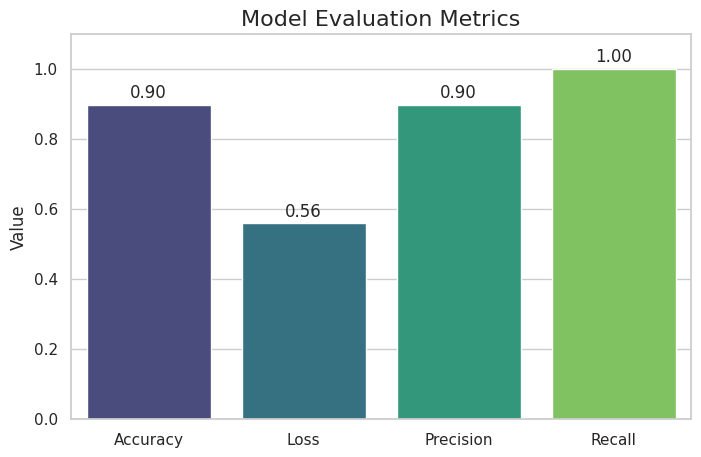

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics from your model.evaluate
metrics = ["Accuracy", "Loss", "Precision", "Recall"]
values = [0.8968, 0.5581, 0.8968, 1.0]

# Set a clean Seaborn style
sns.set(style="whitegrid")

# Create a bar plot
plt.figure(figsize=(8,5))
barplot = sns.barplot(x=metrics, y=values, palette="viridis")

# Annotate bars with values
for index, value in enumerate(values):
    barplot.text(index, value + 0.02, f"{value:.2f}", ha='center', fontsize=12)

plt.title("Model Evaluation Metrics", fontsize=16)
plt.ylim(0, 1.1)  # leave some space for annotations
plt.ylabel("Value", fontsize=12)
plt.show()


In [26]:
!pip install seaborn